In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [16]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import pydicom
from pydicom.data import get_testdata_files
from pydicom.pixel_data_handlers import util

import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [17]:
# Cell 2: Set up data paths
# If you're on Kaggle, use this:
# DATA_DIR = Path("/kaggle/input/rsna-knee-abnormality-detection")

# For local testing, change this to your downloaded folder:
DATA_DIR = Path("../input/competitions/rsna-knee-abnormality-detection")  # adjust as needed

# Define file paths
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_SERIES_CSV = DATA_DIR / "train_series.csv"
TEST_CSV = DATA_DIR / "test.csv"
TEST_SERIES_CSV = DATA_DIR / "test_series.csv"
SAMPLE_SUB = DATA_DIR / "sample_submission.csv"

# DICOM folders
TRAIN_DICOM_DIR = DATA_DIR / "train_series"
TEST_DICOM_DIR = DATA_DIR / "test_series"

# Check if files exist
print(f"Train CSV exists: {TRAIN_CSV.exists()}")
print(f"Train Series CSV exists: {TRAIN_SERIES_CSV.exists()}")
print(f"Train DICOM folder exists: {TRAIN_DICOM_DIR.exists()}")
print(f"Data directory: {DATA_DIR.resolve()}")

Train CSV exists: True
Train Series CSV exists: True
Train DICOM folder exists: True
Data directory: /kaggle/input/competitions/rsna-knee-abnormality-detection


In [18]:
os.listdir("../input/competitions/rsna-knee-abnormality-detection")

['test_series.csv',
 'train_series.csv',
 'sample_submission.csv',
 'test_series',
 'train_series',
 'train.csv',
 'test.csv']

In [19]:
# Cell 3: Load the main training labels
train_df = pd.read_csv(TRAIN_CSV)
print(f"Number of training studies: {len(train_df)}")
print(f"\nColumns:\n{train_df.columns.tolist()}")
print(f"\nFirst 2 rows:")
train_df.head(5)

Number of training studies: 4407

Columns:
['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']

First 2 rows:


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing labels per column:
ACL                 4349
MCL                 4349
Medial Meniscus     4349
Lateral Meniscus    4349
Medial OA           4349
Lateral OA          4349
PF OA               4349
Effusion            4349
Synovitis           4349
Baker's             4349
Contusion           4349
Fracture            4349
dtype: int64

Positive case counts (out of 4407):
Effusion            35.0
Synovitis           27.0
Medial Meniscus     26.0
ACL                 24.0
Lateral Meniscus    23.0
PF OA               21.0
Contusion           19.0
Fracture            18.0
Medial OA           15.0
Baker's             12.0
Lateral OA          11.0
MCL                  9.0
dtype: float64


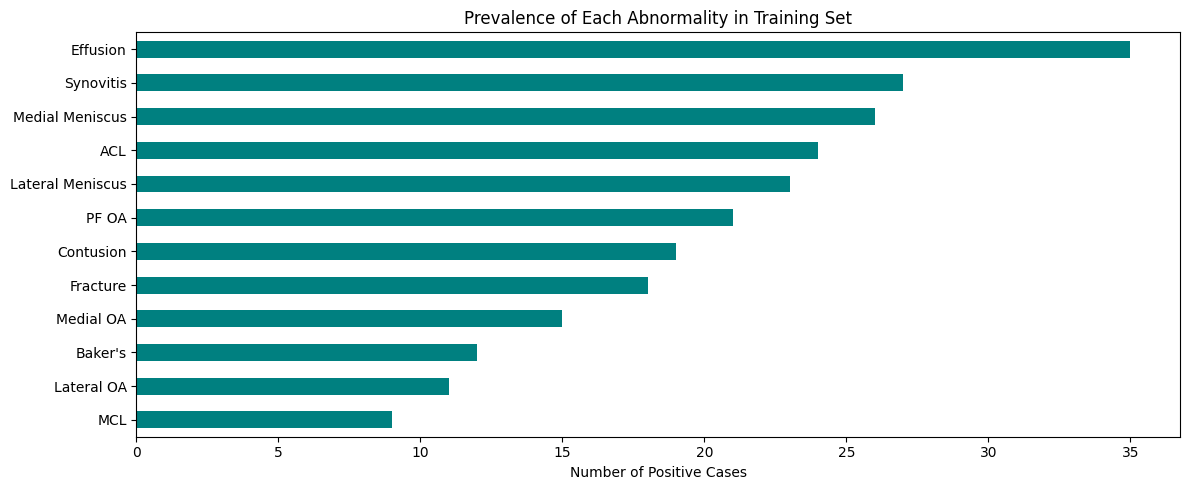

In [20]:
# Cell 4: Explore label distribution (the 12 binary targets)
label_cols = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 
              'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 
              'Synovitis', "Baker's", 'Contusion', 'Fracture']

# Check for missing values
missing_counts = train_df[label_cols].isnull().sum()
print("Missing labels per column:")
print(missing_counts[missing_counts > 0])  # likely all zero, but let's check

# Distribution of positive cases
positive_counts = train_df[label_cols].sum()
print("\nPositive case counts (out of {}):".format(len(train_df)))
print(positive_counts.sort_values(ascending=False))

# Plot distribution
plt.figure(figsize=(12, 5))
positive_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Prevalence of Each Abnormality in Training Set')
plt.xlabel('Number of Positive Cases')
plt.tight_layout()
plt.show()

In [21]:
# Cell 5: Load information about each MRI series (sequence)
series_df = pd.read_csv(TRAIN_SERIES_CSV)
print(f"Number of series rows: {len(series_df)}")
print(f"\nColumns:\n{series_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
series_df.head(3)

# Check unique planes and fluid/fat suppression flags
print("\nAnatomical Planes:", series_df['Anatomical_Plane'].unique())
print("Fluid_Sensitive values:", series_df['Fluid_Sensitive'].unique())
print("Fat_Suppression values:", series_df['Fat_Suppression'].unique())

Number of series rows: 24371

Columns:
['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']

First 3 rows:

Anatomical Planes: ['Sagittal' 'Axial' 'Coronal']
Fluid_Sensitive values: [1 0]
Fat_Suppression values: [1 0]


Series per study: min=3, max=14, median=5


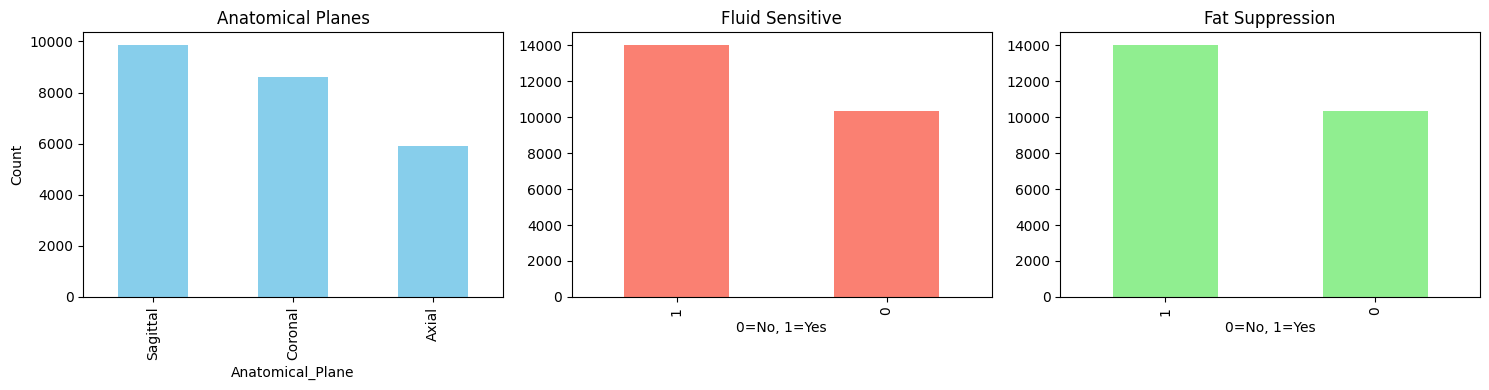


Fluid Sensitive vs Fat Suppression cross-tabulation:
Fat_Suppression      0      1
Fluid_Sensitive              
0                10361      0
1                    0  14010


In [22]:
# Cell 6: How many series per study, and typical sequence types
study_series_count = series_df.groupby('StudyInstanceUID').size()
print(f"Series per study: min={study_series_count.min()}, "
      f"max={study_series_count.max()}, "
      f"median={study_series_count.median():.0f}")

# Distribution of planes
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
series_df['Anatomical_Plane'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Anatomical Planes')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
series_df['Fluid_Sensitive'].value_counts().plot(kind='bar', color='salmon')
plt.title('Fluid Sensitive')
plt.xlabel('0=No, 1=Yes')

plt.subplot(1, 3, 3)
series_df['Fat_Suppression'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Fat Suppression')
plt.xlabel('0=No, 1=Yes')

plt.tight_layout()
plt.show()

# Cross-tab: Fluid sensitive vs Fat suppression
ct = pd.crosstab(series_df['Fluid_Sensitive'], series_df['Fat_Suppression'])
print("\nFluid Sensitive vs Fat Suppression cross-tabulation:")
print(ct)

In [23]:
# Cell 7: Pick a study and look at its radiology report
sample_study = train_df.iloc[0]['StudyInstanceUID']
report_text = train_df.iloc[0]['Report']

print(f"StudyInstanceUID: {sample_study}")
print(f"Labels for this study:\n{train_df.iloc[0][label_cols].to_dict()}")
print("\n--- Radiology Report (first 500 chars) ---")
print(report_text[:500] + "...")

StudyInstanceUID: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
Labels for this study:
{'ACL': nan, 'MCL': nan, 'Medial Meniscus': nan, 'Lateral Meniscus': nan, 'Medial OA': nan, 'Lateral OA': nan, 'PF OA': nan, 'Effusion': nan, 'Synovitis': nan, "Baker's": nan, 'Contusion': nan, 'Fracture': nan}

--- Radiology Report (first 500 chars) ---
Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame....


In [24]:
# Cell 8: Function to load and inspect a single DICOM slice
def load_dicom(filepath):
    """Load a DICOM file and return the dataset."""
    try:
        ds = pydicom.dcmread(filepath, force=True)
        return ds
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

def get_pixel_array(ds):
    """Get pixel array and handle rescaling if needed."""
    arr = ds.pixel_array
    # apply RescaleSlope and RescaleIntercept if present
    if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
        arr = arr * ds.RescaleSlope + ds.RescaleIntercept
    return arr

def show_dicom_slice(filepath, figsize=(6, 6)):
    """Load and display a DICOM slice."""
    ds = load_dicom(filepath)
    if ds is None:
        return
    arr = get_pixel_array(ds)
    plt.figure(figsize=figsize)
    plt.imshow(arr, cmap='gray')
    plt.title(f"Slice: {os.path.basename(filepath)}\n"
              f"Size: {arr.shape}, Plane: {ds.get('ImageOrientationPatient', 'N/A')[:3]}")
    plt.axis('off')
    plt.show()
    return ds, arr

Loading DICOM: ../input/competitions/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.13821229744997220641575291927426543265/1.2.826.0.1.3680043.8.498.12732955977266558882646974219653035510.dcm


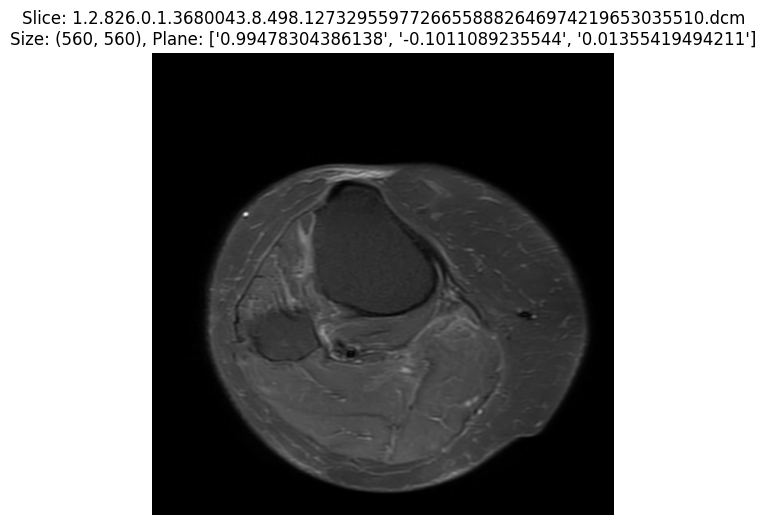


--- Key DICOM Metadata ---
Patient orientation: [0.99478304386138, -0.1011089235544, 0.01355419494211, 0.09998968243598, 0.99273771047592, 0.06688710302114]
Pixel spacing: [0.28771233558654, 0.28771233558654]
Slice thickness: 4
Modality: MR
Manufacturer: Philips Healthcare


In [25]:
# Cell 9: Find the first study and first series with a DICOM file
# Get a study ID from train_df
study_id = train_df.iloc[0]['StudyInstanceUID']
study_dicom_path = TRAIN_DICOM_DIR / study_id

if study_dicom_path.exists():
    # Get list of series folders under this study
    series_folders = [f for f in study_dicom_path.iterdir() if f.is_dir()]
    if series_folders:
        first_series_path = series_folders[0]
        # Get first DICOM file in that series
        dcm_files = list(first_series_path.glob("*.dcm"))
        if dcm_files:
            dcm_path = dcm_files[0]
            print(f"Loading DICOM: {dcm_path}")
            ds, arr = show_dicom_slice(dcm_path)
            
            # Show some key metadata
            print("\n--- Key DICOM Metadata ---")
            print(f"Patient orientation: {ds.get('ImageOrientationPatient', 'Not set')}")
            print(f"Pixel spacing: {ds.get('PixelSpacing', 'Not set')}")
            print(f"Slice thickness: {ds.get('SliceThickness', 'Not set')}")
            print(f"Modality: {ds.get('Modality', 'Not set')}")
            print(f"Manufacturer: {ds.get('Manufacturer', 'Not set')}")
        else:
            print("No .dcm files found in the first series.")
    else:
        print("No series folders found for this study.")
else:
    print(f"Study path does not exist: {study_dicom_path}")
    print("If you are not on Kaggle, you need to download the data first.")

In [26]:
# Cell 10: For one study, list all its series and their properties
study_id = train_df.iloc[0]['StudyInstanceUID']
study_series = series_df[series_df['StudyInstanceUID'] == study_id]

print(f"Study: {study_id}")
print(f"Number of series: {len(study_series)}")
print("\nSeries details:")
for idx, row in study_series.iterrows():
    print(f"  - SeriesUID: {row['SeriesInstanceUID'][:20]}... "
          f"Plane={row['Anatomical_Plane']}, "
          f"Fluid={row['Fluid_Sensitive']}, "
          f"FatSup={row['Fat_Suppression']}")

# Check how many DICOM files are in each series folder
base_path = TRAIN_DICOM_DIR / study_id
if base_path.exists():
    print("\nNumber of slices per series:")
    for series_folder in base_path.iterdir():
        if series_folder.is_dir():
            num_slices = len(list(series_folder.glob("*.dcm")))
            print(f"  - {series_folder.name[:20]}... : {num_slices} slices")

Study: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
Number of series: 5

Series details:
  - SeriesUID: 1.2.826.0.1.3680043.... Plane=Sagittal, Fluid=1, FatSup=1
  - SeriesUID: 1.2.826.0.1.3680043.... Plane=Axial, Fluid=1, FatSup=1
  - SeriesUID: 1.2.826.0.1.3680043.... Plane=Coronal, Fluid=0, FatSup=0
  - SeriesUID: 1.2.826.0.1.3680043.... Plane=Coronal, Fluid=1, FatSup=1
  - SeriesUID: 1.2.826.0.1.3680043.... Plane=Sagittal, Fluid=0, FatSup=0

Number of slices per series:
  - 1.2.826.0.1.3680043.... : 18 slices
  - 1.2.826.0.1.3680043.... : 22 slices
  - 1.2.826.0.1.3680043.... : 16 slices
  - 1.2.826.0.1.3680043.... : 16 slices
  - 1.2.826.0.1.3680043.... : 22 slices


In [27]:
# Cell 11: Look at the test data (just the structure, no DICOMs loaded)
test_df = pd.read_csv(TEST_CSV)
test_series_df = pd.read_csv(TEST_SERIES_CSV)

print(f"Test studies: {len(test_df)} (these are just example rows, replaced at scoring)")
print(f"Test series: {len(test_series_df)}")
print("\nTest DataFrame columns:", test_df.columns.tolist())
print("\nTest series columns:", test_series_df.columns.tolist())

# Note: test.csv does NOT have the 'Report' column

Test studies: 3 (these are just example rows, replaced at scoring)
Test series: 15

Test DataFrame columns: ['StudyInstanceUID']

Test series columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


In [28]:
# Cell 12: Show the sample submission format
sample_sub = pd.read_csv(SAMPLE_SUB)
print(f"Sample submission rows: {len(sample_sub)}")
print("\nFirst 2 rows:")
sample_sub.head(2)

# The expected columns are: StudyInstanceUID, ACL, MCL, ..., Fracture

Sample submission rows: 3

First 2 rows:


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


In [29]:
# Cell 13: Quick summary of the dataset in a markdown-friendly format
print("""
## Dataset Summary (from code)

- Training studies: {}
- Training series: {}
- Test studies (example): {}
- Label columns: {}
- Positive label prevalence (most frequent): {}
- Positive label prevalence (least frequent): {}

- Anatomical planes present: {}
- Average series per study: {:.1f}
- Data size (approx): 569 GB (but we only load DICOMs on demand)
""".format(
    len(train_df),
    len(series_df),
    len(test_df),
    label_cols,
    positive_counts.idxmax() + " (" + str(positive_counts.max()) + ")",
    positive_counts.idxmin() + " (" + str(positive_counts.min()) + ")",
    series_df['Anatomical_Plane'].unique(),
    len(series_df) / len(train_df)
))


## Dataset Summary (from code)

- Training studies: 4407
- Training series: 24371
- Test studies (example): 3
- Label columns: ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
- Positive label prevalence (most frequent): Effusion (35.0)
- Positive label prevalence (least frequent): MCL (9.0)

- Anatomical planes present: ['Sagittal' 'Axial' 'Coronal']
- Average series per study: 5.5
- Data size (approx): 569 GB (but we only load DICOMs on demand)



In [30]:
# Cell 14: Analyze which studies actually have labels
label_cols = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 
              'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 
              'Synovitis', "Baker's", 'Contusion', 'Fracture']

# Find rows where at least one label is not NaN
labeled_mask = train_df[label_cols].notna().any(axis=1)
labeled_df = train_df[label_cols].notna().any(axis=1)
print(f"Total training studies: {len(train_df)}")
print(f"Studies with at least one explicit label: {labeled_mask.sum()}")
print(f"Studies with NO labels: {(~labeled_mask).sum()}")

# Show the label counts again but just for the labeled subset
labeled_subset = train_df[labeled_mask]
print("\nPositive counts in the explicitly labeled subset (N=58):")
print(labeled_subset[label_cols].sum().sort_values(ascending=False))

# Check if any study has multiple labels
multi_label_counts = labeled_subset[label_cols].sum(axis=1)
print(f"\nStudies with >1 abnormality: {(multi_label_counts > 1).sum()}")
print(f"Max abnormalities in one study: {multi_label_counts.max()}")

Total training studies: 4407
Studies with at least one explicit label: 58
Studies with NO labels: 4349

Positive counts in the explicitly labeled subset (N=58):
Effusion            35.0
Synovitis           27.0
Medial Meniscus     26.0
ACL                 24.0
Lateral Meniscus    23.0
PF OA               21.0
Contusion           19.0
Fracture            18.0
Medial OA           15.0
Baker's             12.0
Lateral OA          11.0
MCL                  9.0
dtype: float64

Studies with >1 abnormality: 50
Max abnormalities in one study: 9.0


In [31]:
# Cell 15: Define keyword mappings for each label (English, Spanish, German, French)
import re

LABEL_KEYWORDS = {
    'ACL': [
        'acl', 'anterior cruciate', 'ligamento cruzado anterior', 'vorderes kreuzband',
        'lca', 'rupture du lca', 'croisé antérieur'
    ],
    'MCL': [
        'mcl', 'medial collateral', 'ligamento colateral medial', 'inneres seitenband',
        'ligament collatéral médial', 'rupture mcl'
    ],
    'Medial Meniscus': [
        'menisco medial', 'medial meniscus', 'innenmeniskus', 'ménisque médial',
        'rotura de menisco interno', 'medial meniscal tear'
    ],
    'Lateral Meniscus': [
        'menisco lateral', 'lateral meniscus', 'außenmeniskus', 'ménisque latéral',
        'lateral meniscal tear'
    ],
    'Medial OA': [
        'artrosis medial', 'osteoarthritis medial', 'gonarthrose medial',
        'arthrose fémorotibiale médiale', 'medial compartment osteoarthritis'
    ],
    'Lateral OA': [
        'artrosis lateral', 'osteoarthritis lateral', 'gonarthrose lateral',
        'arthrose fémorotibiale latérale', 'lateral compartment osteoarthritis'
    ],
    'PF OA': [
        'patellofemoral', 'artrosis patelofemoral', 'patellofemorale arthrose',
        'arthrose fémoro-patellaire', 'pf oa'
    ],
    'Effusion': [
        'derrame', 'effusion', 'erguss', 'épanchement', 'joint effusion',
        'líquido intraarticular'
    ],
    'Synovitis': [
        'sinovitis', 'synovitis', 'synovialitis', 'synovite'
    ],
    "Baker's": [
        'baker', 'quiste de baker', 'bakerzyste', 'kyste de baker',
        'popliteal cyst'
    ],
    'Contusion': [
        'contusión', 'contusion', 'bone bruise', 'prellung', 'contusione',
        'edema óseo', 'bone marrow edema'
    ],
    'Fracture': [
        'fractura', 'fracture', 'fraktur', 'fissure', 'fract'
    ]
}

def extract_labels_from_report(text):
    """Return a dict of predicted labels (0/1) based on keyword matching."""
    if not isinstance(text, str):
        return {label: 0 for label in label_cols}
    
    text_lower = text.lower()
    pred = {}
    for label, keywords in LABEL_KEYWORDS.items():
        found = any(re.search(r'\b' + re.escape(kw) + r'\b', text_lower) for kw in keywords)
        pred[label] = 1 if found else 0
    return pred

# Test on the sample report from Cell 7
sample_report = train_df.iloc[0]['Report']
print("Sample report snippet:")
print(sample_report[:200] + "...\n")
print("Extracted labels:")
print(extract_labels_from_report(sample_report))

Sample report snippet:
Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de me...

Extracted labels:
{'ACL': 0, 'MCL': 0, 'Medial Meniscus': 1, 'Lateral Meniscus': 0, 'Medial OA': 0, 'Lateral OA': 0, 'PF OA': 0, 'Effusion': 1, 'Synovitis': 0, "Baker's": 0, 'Contusion': 0, 'Fracture': 0}


In [32]:
# Cell 16: Create pseudo-labels for all training studies
from tqdm import tqdm

# Apply extraction to all reports (this might take a minute)
print("Extracting labels from all reports...")
train_df['pseudo_labels'] = train_df['Report'].apply(extract_labels_from_report)

# Convert pseudo-labels to separate columns
pseudo_df = pd.DataFrame(train_df['pseudo_labels'].tolist(), index=train_df.index)
train_df = pd.concat([train_df, pseudo_df.add_prefix('pseudo_')], axis=1)

# Now compare pseudo-labels vs explicit labels on the 58 labeled studies
labeled_subset = train_df[labeled_mask].copy()
comparison_cols = [f'pseudo_{col}' for col in label_cols]

print("\n--- Validation on the 58 explicitly labeled studies ---")
for col in label_cols:
    explicit = labeled_subset[col].astype(float)
    pseudo = labeled_subset[f'pseudo_{col}'].astype(float)
    # Only compare where explicit is not NaN
    valid = explicit.notna()
    if valid.sum() > 0:
        accuracy = (explicit[valid] == pseudo[valid]).mean()
        print(f"{col:16} | Accuracy: {accuracy:.3f} (N={valid.sum()})")
    else:
        print(f"{col:16} | No explicit labels to compare.")

# Let's check the total number of positive pseudo-labels across all data
print("\n--- Total positive pseudo-labels (all 4407 studies) ---")
total_pseudo_pos = train_df[[f'pseudo_{col}' for col in label_cols]].sum()
print(total_pseudo_pos.sort_values(ascending=False))

Extracting labels from all reports...

--- Validation on the 58 explicitly labeled studies ---
ACL              | Accuracy: 0.517 (N=58)
MCL              | Accuracy: 0.603 (N=58)
Medial Meniscus  | Accuracy: 0.500 (N=58)
Lateral Meniscus | Accuracy: 0.638 (N=58)
Medial OA        | Accuracy: 0.741 (N=58)
Lateral OA       | Accuracy: 0.810 (N=58)
PF OA            | Accuracy: 0.500 (N=58)
Effusion         | Accuracy: 0.466 (N=58)
Synovitis        | Accuracy: 0.621 (N=58)
Baker's          | Accuracy: 0.759 (N=58)
Contusion        | Accuracy: 0.655 (N=58)
Fracture         | Accuracy: 0.690 (N=58)

--- Total positive pseudo-labels (all 4407 studies) ---
pseudo_Effusion            2115
pseudo_Medial Meniscus     1761
pseudo_ACL                 1736
pseudo_Lateral Meniscus    1723
pseudo_MCL                 1652
pseudo_Baker's             1301
pseudo_PF OA               1141
pseudo_Contusion            940
pseudo_Fracture             725
pseudo_Synovitis            419
pseudo_Medial OA        

In [33]:
# Cell 17: DICOM volume loader (returns numpy array per series)
import pydicom
import numpy as np
from pathlib import Path
from collections import defaultdict

def load_series_volume(series_path):
    """Load all DICOM slices in a series folder and return a 3D numpy array."""
    dcm_files = sorted(series_path.glob("*.dcm"))
    if not dcm_files:
        return None
    
    slices = []
    for fpath in dcm_files:
        try:
            ds = pydicom.dcmread(fpath, force=True)
            # Get pixel array and rescale if needed
            arr = ds.pixel_array
            if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
                arr = arr * ds.RescaleSlope + ds.RescaleIntercept
            slices.append(arr)
        except Exception as e:
            print(f"Error reading {fpath.name}: {e}")
            continue
    
    if not slices:
        return None
    
    # Stack along the first axis (z-dimension)
    volume = np.stack(slices, axis=0)  # Shape: (num_slices, H, W)
    return volume.astype(np.float32)

def load_study_volumes(study_id, data_dir=TRAIN_DICOM_DIR):
    """Load all series for a given study ID. Returns dict: {series_uid: volume}."""
    study_path = data_dir / study_id
    if not study_path.exists():
        return {}
    
    volumes = {}
    for series_path in study_path.iterdir():
        if series_path.is_dir():
            series_uid = series_path.name
            vol = load_series_volume(series_path)
            if vol is not None:
                volumes[series_uid] = vol
    return volumes

# Test on the first study
test_study_id = train_df.iloc[0]['StudyInstanceUID']
print(f"Loading volumes for study: {test_study_id}")
volumes = load_study_volumes(test_study_id)
print(f"Loaded {len(volumes)} series:")
for uid, vol in volumes.items():
    print(f"  - {uid[:20]}... shape: {vol.shape}")

Loading volumes for study: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
Loaded 5 series:
  - 1.2.826.0.1.3680043.... shape: (18, 560, 560)
  - 1.2.826.0.1.3680043.... shape: (22, 640, 640)
  - 1.2.826.0.1.3680043.... shape: (16, 560, 560)
  - 1.2.826.0.1.3680043.... shape: (16, 576, 576)
  - 1.2.826.0.1.3680043.... shape: (22, 512, 512)


Showing montage for series: 1.2.826.0.1.3680043.8.498.1382...
Volume shape: (18, 560, 560) (slices x height x width)


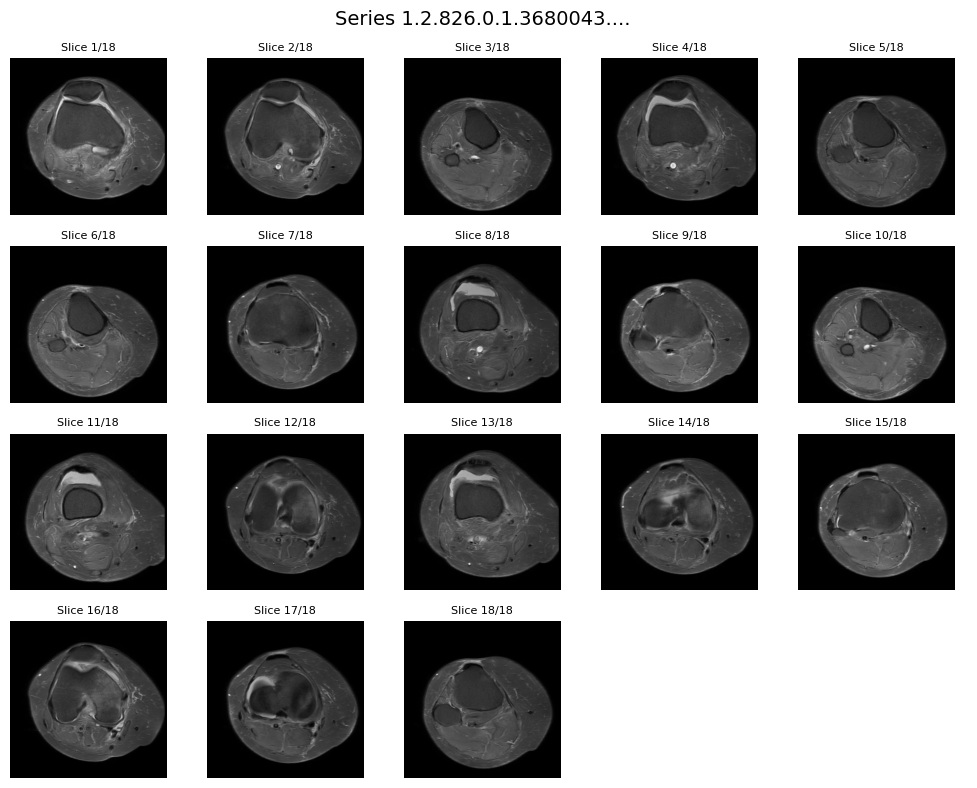

In [34]:
# Cell 18: Display a montage of all slices in a series
import matplotlib.pyplot as plt

def show_volume_montage(volume, title="Volume Montage", cols=6):
    """Display a grid of slices from a 3D volume."""
    num_slices = volume.shape[0]
    rows = (num_slices + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()
    
    for i in range(num_slices):
        axes[i].imshow(volume[i], cmap='gray')
        axes[i].set_title(f"Slice {i+1}/{num_slices}", fontsize=8)
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_slices, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Get the first series volume from the test study
first_series_uid = list(volumes.keys())[0]
first_volume = volumes[first_series_uid]

print(f"Showing montage for series: {first_series_uid[:30]}...")
print(f"Volume shape: {first_volume.shape} (slices x height x width)")
show_volume_montage(first_volume, title=f"Series {first_series_uid[:20]}...", cols=5)

In [37]:
# Cell 19: Create final labels for training
# Strategy: Use explicit labels if available, otherwise use pseudo-labels
for col in label_cols:
    # Start with pseudo-labels
    train_df[f'final_{col}'] = train_df[f'pseudo_{col}'].astype(float)
    # Override with explicit labels where they exist
    explicit_mask = train_df[col].notna()
    train_df.loc[explicit_mask, f'final_{col}'] = train_df.loc[explicit_mask, col].astype(float)

# Check the distribution of final labels
print("Final label distribution (all 4407 studies):")
final_pos_counts = train_df[[f'final_{col}' for col in label_cols]].sum()
print(final_pos_counts.sort_values(ascending=False))

# Save this merged dataframe for later use
train_df.to_csv("train_with_pseudolabels.csv", index=False)
print("\nSaved merged dataframe to 'train_with_pseudolabels.csv'")

KeyError: 'pseudo_ACL'

In [38]:
# Cell 20: Minimal PyTorch-style data loader (no batching yet)
from torch.utils.data import Dataset, DataLoader
import torch

class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, label_cols, target_cols='final_'):
        self.df = df
        self.dicom_dir = Path(dicom_dir)
        self.label_cols = label_cols
        self.target_cols = [f'{target_cols}{col}' for col in label_cols]
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = row['StudyInstanceUID']
        
        # Load volumes (you might want to cache this or load on the fly)
        volumes = load_study_volumes(study_id, self.dicom_dir)
        
        # For simplicity, just pick the sagittal fluid-sensitive series
        # (we'll add proper series selection later)
        # Here we just take the first volume available
        if volumes:
            first_vol = list(volumes.values())[0]
            # Resize to fixed shape? We'll skip for now.
            volume_tensor = torch.tensor(first_vol, dtype=torch.float32).unsqueeze(0)  # Add channel dim
        else:
            volume_tensor = torch.zeros((1, 1, 1))  # dummy
        
        # Get labels
        labels = torch.tensor(row[self.target_cols].values.astype(float), dtype=torch.float32)
        
        return {
            'study_id': study_id,
            'volume': volume_tensor,
            'labels': labels,
            'has_explicit_label': row[self.label_cols].notna().any()
        }

# Test the dataset
ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, label_cols)
sample = ds[0]
print(f"Sample study: {sample['study_id'][:30]}...")
print(f"Volume shape: {sample['volume'].shape}")
print(f"Labels: {sample['labels'].tolist()}")
print(f"Has explicit label: {sample['has_explicit_label']}")

KeyError: "None of [Index(['final_ACL', 'final_MCL', 'final_Medial Meniscus',\n       'final_Lateral Meniscus', 'final_Medial OA', 'final_Lateral OA',\n       'final_PF OA', 'final_Effusion', 'final_Synovitis', 'final_Baker's',\n       'final_Contusion', 'final_Fracture'],\n      dtype='object')] are in the [index]"

In [23]:
# Cell 21: Preprocessing functions for DICOM volumes
import cv2
import numpy as np
from scipy.ndimage import zoom

TARGET_SIZE = 224          # square size for each slice
TARGET_SLICES = 30         # fixed number of slices per volume

def preprocess_volume(volume, target_size=TARGET_SIZE, target_slices=TARGET_SLICES):
    """
    Input:  volume (np.ndarray) of shape (num_slices, H, W)
    Output: (target_slices, target_size, target_size) float32 normalized to [0,1]
    """
    if volume is None or volume.shape[0] == 0:
        return None
    
    # 1. Resize each slice to target_size x target_size
    resized_slices = []
    for slice_img in volume:
        # ensure 2D
        if slice_img.ndim == 2:
            resized = cv2.resize(slice_img, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        else:
            # sometimes we might have 3D? just take first channel if so
            resized = cv2.resize(slice_img[:,:,0], (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        resized_slices.append(resized)
    
    # 2. Stack and clip to percentile to remove extreme outliers
    vol_stack = np.stack(resized_slices, axis=0).astype(np.float32)
    high_percentile = np.percentile(vol_stack, 99.5)
    low_percentile = np.percentile(vol_stack, 0.5)
    vol_stack = np.clip(vol_stack, low_percentile, high_percentile)
    
    # 3. Normalize to [0,1] (if range > 0)
    range_val = high_percentile - low_percentile
    if range_val > 0:
        vol_stack = (vol_stack - low_percentile) / range_val
    else:
        vol_stack = vol_stack - low_percentile  # all zeros if constant
    
    # 4. Pad or truncate to target_slices
    current_slices = vol_stack.shape[0]
    if current_slices < target_slices:
        # Pad with zeros at the beginning and end (or copy the first/last slice)
        pad_before = (target_slices - current_slices) // 2
        pad_after = target_slices - current_slices - pad_before
        vol_stack = np.pad(vol_stack, ((pad_before, pad_after), (0,0), (0,0)), mode='edge')
    elif current_slices > target_slices:
        # Take middle slices
        start = (current_slices - target_slices) // 2
        vol_stack = vol_stack[start:start+target_slices, :, :]
    
    return vol_stack.astype(np.float32)

# Test on our loaded volume
sample_vol = volumes[first_series_uid]
preprocessed = preprocess_volume(sample_vol)
print(f"Original shape: {sample_vol.shape} -> preprocessed shape: {preprocessed.shape}")
print(f"Min: {preprocessed.min():.3f}, Max: {preprocessed.max():.3f}, Mean: {preprocessed.mean():.3f}")

Original shape: (18, 560, 560) -> preprocessed shape: (30, 224, 224)
Min: 0.000, Max: 1.000, Mean: 0.231


In [24]:
# Cell 22: Dataset with caching and series selection
import hashlib
import pickle
from pathlib import Path
from torch.utils.data import Dataset

CACHE_DIR = Path("./volume_cache")
CACHE_DIR.mkdir(exist_ok=True)

class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, label_cols, target_cols='final_', 
                 target_size=224, target_slices=30, use_cache=True):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = Path(dicom_dir)
        self.label_cols = label_cols
        self.target_cols = [f'{target_cols}{col}' for col in label_cols]
        self.target_size = target_size
        self.target_slices = target_slices
        self.use_cache = use_cache
        
        # Prefer sagittal fluid-sensitive series (Fluid_Sensitive=1, Anatomical_Plane='Sagittal')
        self.series_df = pd.read_csv(self.dicom_dir.parent / "train_series.csv")
        # Map study -> list of series uids with their attributes
        self.study_series_map = {}
        for study_id, group in self.series_df.groupby('StudyInstanceUID'):
            # Sort: prioritize Sagittal with Fluid_Sensitive=1, then any Sagittal, etc.
            # We'll just take the first in a specific order
            # Let's create a priority score: Sagittal & Fluid=1: 4, Sagittal: 3, Coronal & Fluid=1:2, others:1
            def priority(row):
                score = 0
                if row['Anatomical_Plane'] == 'Sagittal':
                    score += 2
                if row['Fluid_Sensitive'] == 1:
                    score += 2
                return score
            group = group.copy()
            group['priority'] = group.apply(priority, axis=1)
            group = group.sort_values('priority', ascending=False)
            self.study_series_map[study_id] = group['SeriesInstanceUID'].tolist()
    
    def __len__(self):
        return len(self.df)
    
    def _get_cached_volume(self, study_id, series_uid):
        # Create a unique cache key based on study, series, and preprocessing params
        cache_key = f"{study_id}_{series_uid}_{self.target_size}_{self.target_slices}"
        cache_file = CACHE_DIR / f"{hashlib.md5(cache_key.encode()).hexdigest()}.pkl"
        if self.use_cache and cache_file.exists():
            with open(cache_file, 'rb') as f:
                return pickle.load(f)
        return None
    
    def _cache_volume(self, study_id, series_uid, volume):
        cache_key = f"{study_id}_{series_uid}_{self.target_size}_{self.target_slices}"
        cache_file = CACHE_DIR / f"{hashlib.md5(cache_key.encode()).hexdigest()}.pkl"
        with open(cache_file, 'wb') as f:
            pickle.dump(volume, f)
        return volume
    
    def load_volume_for_study(self, study_id):
        # Get the preferred series for this study
        series_list = self.study_series_map.get(study_id, [])
        if not series_list:
            return None
        # Try each series in priority order until we find one that loads
        for series_uid in series_list:
            cached = self._get_cached_volume(study_id, series_uid)
            if cached is not None:
                return cached
            # Load raw volume
            series_path = self.dicom_dir / study_id / series_uid
            raw_vol = load_series_volume(series_path)
            if raw_vol is not None:
                processed = preprocess_volume(raw_vol, self.target_size, self.target_slices)
                if processed is not None:
                    # Cache it
                    self._cache_volume(study_id, series_uid, processed)
                    return processed
        return None
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = row['StudyInstanceUID']
        volume = self.load_volume_for_study(study_id)
        if volume is None:
            # fallback: zeros
            volume = np.zeros((self.target_slices, self.target_size, self.target_size), dtype=np.float32)
        
        # Convert to tensor (add channel dim: C=1)
        volume_tensor = torch.tensor(volume, dtype=torch.float32).unsqueeze(0)  # (1, slices, H, W)
        
        # Labels
        labels = torch.tensor(row[self.target_cols].values.astype(np.float32), dtype=torch.float32)
        
        return {
            'study_id': study_id,
            'volume': volume_tensor,
            'labels': labels
        }

# Test dataset with caching
ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, label_cols)
sample = ds[0]
print(f"Volume shape: {sample['volume'].shape}")  # (1, 30, 224, 224)
print(f"Labels: {sample['labels'].shape}, sum: {sample['labels'].sum().item()}")

Volume shape: torch.Size([1, 30, 224, 224])
Labels: torch.Size([12]), sum: 2.0


In [25]:
# Cell 23: Model definition
import torch.nn as nn
import torchvision.models as models

class SliceAggregationModel(nn.Module):
    def __init__(self, num_labels=12, backbone='resnet18', pretrained=True):
        super().__init__()
        # Load pretrained backbone
        if backbone == 'resnet18':
            self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
            feat_dim = 512
        else:
            raise ValueError("Only resnet18 for now")
        # Remove the final FC layer
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])  # keep up to avgpool
        # We'll use adaptive avg pooling to get a fixed feature vector per slice
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        # Classifier for each slice? We'll aggregate first.
        # Instead, we'll compute features per slice, then average across slices, then classify.
        self.classifier = nn.Linear(feat_dim, num_labels)
    
    def forward(self, x):
        # x shape: (batch, 1, slices, H, W) -> we need to reshape to (batch*slices, 1, H, W)
        batch, _, slices, H, W = x.shape
        # Combine batch and slices dimensions: (batch*slices, 1, H, W)
        x_flat = x.view(batch * slices, 1, H, W)
        # Repeat the 1-channel to 3-channel for ResNet (pretrained expects 3)
        x_rgb = x_flat.repeat(1, 3, 1, 1)
        # Pass through backbone
        features = self.backbone(x_rgb)  # (batch*slices, 512, H', W')  but after avgpool we'll get features
        # Global average pooling: (batch*slices, 512, 1, 1) -> (batch*slices, 512)
        features = self.avgpool(features).view(batch * slices, -1)
        # Average across slices: (batch, slices, 512) -> (batch, 512)
        features = features.view(batch, slices, -1).mean(dim=1)
        # Classify
        logits = self.classifier(features)
        return logits

# Test with a dummy batch
model = SliceAggregationModel(num_labels=12)
dummy = torch.randn(4, 1, 30, 224, 224)  # batch=4
out = model(dummy)
print(f"Output shape: {out.shape}")  # (4, 12)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


Output shape: torch.Size([4, 12])


In [26]:
# Cell 24: Training setup and loop
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 4   # adjust based on GPU memory
EPOCHS = 5
LR = 1e-4

# Data splits: we'll use a simple 80/20 train/val split
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(range(len(ds)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(ds, train_idx)
val_dataset = torch.utils.data.Subset(ds, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

model = SliceAggregationModel(num_labels=12).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def compute_auc(labels, preds):
    """Compute macro AUC over 12 labels."""
    aucs = []
    for i in range(labels.shape[1]):
        if labels[:, i].sum() > 0 and (labels[:, i] == 0).sum() > 0:
            try:
                auc = roc_auc_score(labels[:, i].cpu().numpy(), preds[:, i].cpu().numpy())
                aucs.append(auc)
            except:
                pass
    return np.mean(aucs) if aucs else 0.0

# Training loop
best_val_auc = 0.0
for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    start_time = time.time()
    for batch in train_loader:
        volumes = batch['volume'].to(device)   # (B, 1, S, H, W)
        labels = batch['labels'].to(device)    # (B, 12)
        optimizer.zero_grad()
        logits = model(volumes)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(volumes)
    train_loss /= len(train_dataset)
    
    # Validation
    model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for batch in val_loader:
            volumes = batch['volume'].to(device)
            labels = batch['labels'].to(device)
            logits = model(volumes)
            loss = criterion(logits, labels)
            val_loss += loss.item() * len(volumes)
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(logits).cpu())
    val_loss /= len(val_dataset)
    all_labels = torch.cat(all_labels, dim=0)
    all_preds = torch.cat(all_preds, dim=0)
    val_auc = compute_auc(all_labels, all_preds)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Time: {elapsed:.1f}s")
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "best_model.pth")
        print("  -> Saved best model")

print(f"\nBest validation AUC: {best_val_auc:.4f}")

Using device: cuda


KeyboardInterrupt: 

In [27]:
## OPTIMIZED GPU

In [28]:
# Cell 24: Optimized Training with Full GPU Utilization & Detailed Logging
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
import time
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import gc

# ---------- Device Setup ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_count = torch.cuda.device_count()
print(f"Using device: {device} | GPUs available: {gpu_count}")
if gpu_count > 0:
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# ---------- Hyperparameters ----------
BATCH_SIZE = 16              # Start here. T4 16GB can handle ~16-24 with ResNet18 & AMP.
EPOCHS = 10                  # Increase if you see AUC improving.
LR = 1e-4
NUM_WORKERS = 4              # Kaggle CPU cores: use 4-8.
PIN_MEMORY = True
USE_AMP = True               # Mixed precision saves ~40% VRAM.
GRAD_ACCUM_STEPS = 1         # Set >1 to simulate larger batch (e.g., 2 -> effective batch 32).

# ---------- Data Splits ----------
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(range(len(ds)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(ds, train_idx)
val_dataset = torch.utils.data.Subset(ds, val_idx)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    drop_last=True  # avoids small uneven batches
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

# ---------- Model (with DataParallel for multi-GPU) ----------
model = SliceAggregationModel(num_labels=12).to(device)
if gpu_count > 1:
    model = nn.DataParallel(model)
    print(f"✅ Wrapped model with DataParallel ({gpu_count} GPUs)")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler(enabled=USE_AMP)

# ---------- AUC Functions ----------
def compute_per_label_auc(labels, preds, label_names):
    """Returns dict of AUC per label and macro average."""
    auc_dict = {}
    valid_aucs = []
    for i, name in enumerate(label_names):
        if labels[:, i].sum() > 0 and (labels[:, i] == 0).sum() > 0:
            try:
                auc = roc_auc_score(labels[:, i].cpu().numpy(), preds[:, i].cpu().numpy())
                auc_dict[name] = auc
                valid_aucs.append(auc)
            except Exception as e:
                auc_dict[name] = float('nan')
        else:
            auc_dict[name] = float('nan')
    macro_auc = np.nanmean(valid_aucs) if valid_aucs else 0.0
    return auc_dict, macro_auc

def format_auc_string(auc_dict, decimals=3):
    """Format per-label AUCs into a compact string."""
    parts = []
    for k, v in auc_dict.items():
        if not np.isnan(v):
            parts.append(f"{k}={v:.{decimals}f}")
        else:
            parts.append(f"{k}=nan")
    return " | ".join(parts)

# ---------- Training Loop ----------
best_val_auc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    start_time = time.time()
    
    # Progress bar for training
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    optimizer.zero_grad()
    
    for batch_idx, batch in enumerate(train_pbar):
        volumes = batch['volume'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        
        # Mixed precision forward
        with autocast(enabled=USE_AMP):
            logits = model(volumes)
            loss = criterion(logits, labels)
            loss = loss / GRAD_ACCUM_STEPS  # normalize for accumulation
        
        # Backward
        scaler.scale(loss).backward()
        
        # Gradient accumulation step
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or (batch_idx + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        train_loss += loss.item() * volumes.size(0) * GRAD_ACCUM_STEPS  # rescale loss
        
        # Update progress bar with current loss
        train_pbar.set_postfix({'loss': f'{loss.item() * GRAD_ACCUM_STEPS:.4f}'})
    
    avg_train_loss = train_loss / len(train_dataset)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Valid]", leave=False)
    with torch.no_grad():
        for batch in val_pbar:
            volumes = batch['volume'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            
            with autocast(enabled=USE_AMP):
                logits = model(volumes)
                loss = criterion(logits, labels)
            
            val_loss += loss.item() * volumes.size(0)
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(logits).cpu())
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_val_loss = val_loss / len(val_dataset)
    all_labels = torch.cat(all_labels, dim=0)
    all_preds = torch.cat(all_preds, dim=0)
    
    # Compute detailed AUCs
    per_label_auc, macro_auc = compute_per_label_auc(all_labels, all_preds, label_cols)
    
    # GPU Memory stats
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(device) / 1024**3
        reserved = torch.cuda.memory_reserved(device) / 1024**3
        mem_str = f"GPU Mem: {allocated:.2f}/{reserved:.2f} GB"
    else:
        mem_str = "GPU Mem: N/A"
    
    elapsed = time.time() - start_time
    
    # --- Epoch Summary (Rich Logging) ---
    print(f"\n{'='*80}")
    print(f"Epoch {epoch:2d}/{EPOCHS} | Time: {elapsed:.1f}s | {mem_str}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro AUC: {macro_auc:.4f}")
    print(f"  Per-label AUC: {format_auc_string(per_label_auc)}")
    
    # Save best model
    if macro_auc > best_val_auc:
        best_val_auc = macro_auc
        best_epoch = epoch
        # Handle DataParallel wrapper
        state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state_dict, "best_model.pth")
        print(f"  ✅ Saved new best model (AUC: {best_val_auc:.4f})")
    else:
        print(f"  Best so far: epoch {best_epoch} (AUC: {best_val_auc:.4f})")
    print(f"{'='*80}\n")
    
    # Clean up GPU cache between epochs (optional)
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n🎉 Training complete! Best validation AUC: {best_val_auc:.4f} (epoch {best_epoch})")

Using device: cuda | GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
✅ Wrapped model with DataParallel (2 GPUs)


OSError: Caught OSError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataset.py", line 413, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_58/4066475216.py", line 84, in __getitem__
    volume = self.load_volume_for_study(study_id)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_58/4066475216.py", line 77, in load_volume_for_study
    self._cac

In [29]:
# Cell 22 (Revised): Dataset with preloading (no disk cache)
import numpy as np
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
import gc

class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, label_cols, target_cols='final_', 
                 target_size=128, target_slices=30, preload=True):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = Path(dicom_dir)
        self.label_cols = label_cols
        self.target_cols = [f'{target_cols}{col}' for col in label_cols]
        self.target_size = target_size
        self.target_slices = target_slices
        
        # Load series metadata to select preferred series
        self.series_df = pd.read_csv(self.dicom_dir.parent / "train_series.csv")
        self.study_series_map = {}
        for study_id, group in self.series_df.groupby('StudyInstanceUID'):
            def priority(row):
                score = 0
                if row['Anatomical_Plane'] == 'Sagittal':
                    score += 2
                if row['Fluid_Sensitive'] == 1:
                    score += 2
                return score
            group = group.copy()
            group['priority'] = group.apply(priority, axis=1)
            group = group.sort_values('priority', ascending=False)
            self.study_series_map[study_id] = group['SeriesInstanceUID'].tolist()
        
        # Preload all volumes if requested
        self.volumes = None
        if preload:
            self.volumes = [None] * len(self.df)
            print("Preloading all volumes... (this may take a few minutes)")
            for idx in tqdm(range(len(self.df)), desc="Loading volumes"):
                study_id = self.df.iloc[idx]['StudyInstanceUID']
                vol = self._load_and_preprocess(study_id)
                self.volumes[idx] = vol
            print(f"Preloading complete. Memory used: ~{self._estimate_memory()/1e9:.2f} GB")
    
    def _estimate_memory(self):
        # Rough estimate: each volume is target_slices * target_size^2 * 4 bytes
        size_per_vol = self.target_slices * self.target_size * self.target_size * 4
        total = size_per_vol * len(self.df)
        return total
    
    def _load_and_preprocess(self, study_id):
        # Get preferred series
        series_list = self.study_series_map.get(study_id, [])
        if not series_list:
            return None
        for series_uid in series_list:
            series_path = self.dicom_dir / study_id / series_uid
            raw_vol = load_series_volume(series_path)  # from earlier
            if raw_vol is not None:
                processed = preprocess_volume(raw_vol, self.target_size, self.target_slices)
                if processed is not None:
                    return processed
        return None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        if self.volumes is not None:
            volume = self.volumes[idx]
        else:
            study_id = self.df.iloc[idx]['StudyInstanceUID']
            volume = self._load_and_preprocess(study_id)
        
        if volume is None:
            volume = np.zeros((self.target_slices, self.target_size, self.target_size), dtype=np.float32)
        
        volume_tensor = torch.tensor(volume, dtype=torch.float32).unsqueeze(0)  # (1, S, H, W)
        labels = torch.tensor(self.df.iloc[idx][self.target_cols].values.astype(np.float32), dtype=torch.float32)
        return {'volume': volume_tensor, 'labels': labels}

# Instantiate dataset with preload=True
ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, label_cols, target_size=128, target_slices=30, preload=True)

Preloading all volumes... (this may take a few minutes)


Loading volumes:  12%|█▏        | 533/4407 [05:07<37:14,  1.73it/s]  


KeyboardInterrupt: 

In [33]:
# Cell 1: Dataset with parallel loading (no preload)
import os, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import pydicom
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path("/kaggle/input/rsna-knee-abnormality-detection")
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_SERIES_CSV = DATA_DIR / "train_series.csv"
TEST_CSV = DATA_DIR / "test.csv"
TEST_SERIES_CSV = DATA_DIR / "test_series.csv"
TRAIN_DICOM_DIR = DATA_DIR / "train_series"

train_df = pd.read_csv(TRAIN_CSV)
series_df = pd.read_csv(TRAIN_SERIES_CSV)
label_cols = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
              'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
              'Synovitis', "Baker's", 'Contusion', 'Fracture']

# ---------- Helpers ----------
def load_series_volume(series_path):
    dcm_files = sorted(series_path.glob("*.dcm"))
    if not dcm_files:
        return None
    slices = []
    for fpath in dcm_files:
        try:
            ds = pydicom.dcmread(fpath, force=True)
            arr = ds.pixel_array
            if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
                arr = arr * ds.RescaleSlope + ds.RescaleIntercept
            slices.append(arr)
        except:
            continue
    if not slices:
        return None
    return np.stack(slices, axis=0).astype(np.float32)

def preprocess_volume(volume, target_size=224, target_slices=30):
    if volume is None or volume.shape[0] == 0:
        return None
    # Resize each slice to target_size
    resized = []
    for sl in volume:
        if sl.ndim == 3:
            sl = sl[:,:,0]
        r = cv2.resize(sl, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        resized.append(r)
    vol = np.stack(resized, axis=0).astype(np.float32)
    # Clip & normalize
    hi = np.percentile(vol, 99.5)
    lo = np.percentile(vol, 0.5)
    vol = np.clip(vol, lo, hi)
    if hi > lo:
        vol = (vol - lo) / (hi - lo)
    else:
        vol = vol - lo
    # Pad/truncate slices
    cur = vol.shape[0]
    if cur < target_slices:
        pad_before = (target_slices - cur) // 2
        pad_after = target_slices - cur - pad_before
        vol = np.pad(vol, ((pad_before, pad_after), (0,0), (0,0)), mode='edge')
    elif cur > target_slices:
        start = (cur - target_slices) // 2
        vol = vol[start:start+target_slices, :, :]
    return vol

# ---------- Dataset (no preload) ----------
class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, series_df, label_cols, target_cols='final_',
                 target_size=224, target_slices=30):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = Path(dicom_dir)
        self.label_cols = label_cols
        self.target_cols = [f'{target_cols}{col}' for col in label_cols]
        self.target_size = target_size
        self.target_slices = target_slices
        # Build series priority map
        self.study_series_map = {}
        for study_id, group in series_df.groupby('StudyInstanceUID'):
            def priority(row):
                score = 0
                if row['Anatomical_Plane'] == 'Sagittal':
                    score += 2
                if row['Fluid_Sensitive'] == 1:
                    score += 2
                return score
            group = group.copy()
            group['priority'] = group.apply(priority, axis=1)
            group = group.sort_values('priority', ascending=False)
            self.study_series_map[study_id] = group['SeriesInstanceUID'].tolist()
    
    def _load_one(self, study_id):
        series_list = self.study_series_map.get(study_id, [])
        for series_uid in series_list:
            series_path = self.dicom_dir / study_id / series_uid
            raw = load_series_volume(series_path)
            if raw is not None:
                proc = preprocess_volume(raw, self.target_size, self.target_slices)
                if proc is not None:
                    return proc
        return None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        study_id = self.df.iloc[idx]['StudyInstanceUID']
        vol = self._load_one(study_id)
        if vol is None:
            vol = np.zeros((self.target_slices, self.target_size, self.target_size), dtype=np.float32)
        vol_tensor = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)  # (1, S, H, W)
        labels = torch.tensor(self.df.iloc[idx][self.target_cols].values.astype(np.float32), dtype=torch.float32)
        return {'volume': vol_tensor, 'labels': labels}

# ---------- Instantiate (no preload) ----------
ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, series_df, label_cols,
                    target_size=224, target_slices=30)   # <-- now 224, no resize in model

# ---------- Model (no resize needed) ----------
class SliceAggregationModel(nn.Module):
    def __init__(self, num_labels=12, backbone='resnet18', pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(512, num_labels)
    
    def forward(self, x):
        batch, _, slices, H, W = x.shape
        x_flat = x.view(batch * slices, 1, H, W)
        x_rgb = x_flat.repeat(1, 3, 1, 1)          # input is now 224x224 already
        features = self.backbone(x_rgb)
        features = self.avgpool(features)
        features = features.view(batch * slices, -1)
        features = features.view(batch, slices, -1).mean(dim=1)
        return self.classifier(features)

print("✅ Cell 1 complete. Dataset (no preload) and model ready.")

Preloading 4407 studies (target_size=128)...


Loading volumes:   9%|▊         | 379/4407 [01:18<13:54,  4.82it/s]


KeyboardInterrupt: 

In [9]:
# Cell 1: Dataset with parallel loading (no preload)
import os, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import pydicom
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
DATA_DIR = Path("../input/competitions/rsna-knee-abnormality-detection")  # adjust as needed

TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_SERIES_CSV = DATA_DIR / "train_series.csv"
TEST_CSV = DATA_DIR / "test.csv"
TEST_SERIES_CSV = DATA_DIR / "test_series.csv"
TRAIN_DICOM_DIR = DATA_DIR / "train_series"

train_df = pd.read_csv(TRAIN_CSV)
series_df = pd.read_csv(TRAIN_SERIES_CSV)
label_cols = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
              'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
              'Synovitis', "Baker's", 'Contusion', 'Fracture']

# ---------- Helpers ----------
def load_series_volume(series_path):
    dcm_files = sorted(series_path.glob("*.dcm"))
    if not dcm_files:
        return None
    slices = []
    for fpath in dcm_files:
        try:
            ds = pydicom.dcmread(fpath, force=True)
            arr = ds.pixel_array
            if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
                arr = arr * ds.RescaleSlope + ds.RescaleIntercept
            slices.append(arr)
        except:
            continue
    if not slices:
        return None
    return np.stack(slices, axis=0).astype(np.float32)

def preprocess_volume(volume, target_size=224, target_slices=30):
    if volume is None or volume.shape[0] == 0:
        return None
    resized = []
    for sl in volume:
        if sl.ndim == 3:
            sl = sl[:,:,0]
        r = cv2.resize(sl, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        resized.append(r)
    vol = np.stack(resized, axis=0).astype(np.float32)
    hi = np.percentile(vol, 99.5)
    lo = np.percentile(vol, 0.5)
    vol = np.clip(vol, lo, hi)
    if hi > lo:
        vol = (vol - lo) / (hi - lo)
    else:
        vol = vol - lo
    cur = vol.shape[0]
    if cur < target_slices:
        pad_before = (target_slices - cur) // 2
        pad_after = target_slices - cur - pad_before
        vol = np.pad(vol, ((pad_before, pad_after), (0,0), (0,0)), mode='edge')
    elif cur > target_slices:
        start = (cur - target_slices) // 2
        vol = vol[start:start+target_slices, :, :]
    return vol

# ---------- Dataset (no preload) ----------
class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, series_df, label_cols, target_cols='pseudo_',
                 target_size=224, target_slices=30):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = Path(dicom_dir)
        self.label_cols = label_cols
        # Determine which target columns exist
        possible_prefixes = ['final_', 'pseudo_', '']
        found_cols = None
        for prefix in possible_prefixes:
            test_cols = [f'{prefix}{col}' for col in label_cols]
            if all(col in self.df.columns for col in test_cols):
                found_cols = test_cols
                break
        if found_cols is None:
            # Fallback: use zeros (but we'll warn)
            print("⚠️ No label columns found! Using zeros.")
            self.df = self.df.copy()
            for col in label_cols:
                self.df[f'fallback_{col}'] = 0.0
            found_cols = [f'fallback_{col}' for col in label_cols]
        self.target_cols = found_cols
        print(f"✅ Using target columns: {self.target_cols[:2]}...")
        
        self.target_size = target_size
        self.target_slices = target_slices
        # Build series priority map
        self.study_series_map = {}
        for study_id, group in series_df.groupby('StudyInstanceUID'):
            def priority(row):
                score = 0
                if row['Anatomical_Plane'] == 'Sagittal':
                    score += 2
                if row['Fluid_Sensitive'] == 1:
                    score += 2
                return score
            group = group.copy()
            group['priority'] = group.apply(priority, axis=1)
            group = group.sort_values('priority', ascending=False)
            self.study_series_map[study_id] = group['SeriesInstanceUID'].tolist()
    
    def _load_one(self, study_id):
        series_list = self.study_series_map.get(study_id, [])
        for series_uid in series_list:
            series_path = self.dicom_dir / study_id / series_uid
            raw = load_series_volume(series_path)
            if raw is not None:
                proc = preprocess_volume(raw, self.target_size, self.target_slices)
                if proc is not None:
                    return proc
        return None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        study_id = self.df.iloc[idx]['StudyInstanceUID']
        vol = self._load_one(study_id)
        if vol is None:
            vol = np.zeros((self.target_slices, self.target_size, self.target_size), dtype=np.float32)
        vol_tensor = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)  # (1, S, H, W)
        labels = torch.tensor(self.df.iloc[idx][self.target_cols].values.astype(np.float32), dtype=torch.float32)
        return {'volume': vol_tensor, 'labels': labels}

# ---------- Instantiate dataset ----------
# It will automatically pick 'final_' if exists, else 'pseudo_', else fallback zeros.
ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, series_df, label_cols,
                    target_size=224, target_slices=30)

# ---------- Model (no resize needed) ----------
class SliceAggregationModel(nn.Module):
    def __init__(self, num_labels=12, backbone='resnet18', pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(512, num_labels)
    
    def forward(self, x):
        batch, _, slices, H, W = x.shape
        x_flat = x.view(batch * slices, 1, H, W)
        x_rgb = x_flat.repeat(1, 3, 1, 1)          # input is 224x224
        features = self.backbone(x_rgb)
        features = self.avgpool(features)
        features = features.view(batch * slices, -1)
        features = features.view(batch, slices, -1).mean(dim=1)
        return self.classifier(features)

print("✅ Cell 1 complete. Dataset (no preload) and model ready.")

✅ Using target columns: ['ACL', 'MCL']...
✅ Cell 1 complete. Dataset (no preload) and model ready.


In [10]:
# Cell 2: Optimized training with DataLoader workers (same as before)
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_count = torch.cuda.device_count()
print(f"GPUs: {gpu_count}")

BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
USE_AMP = True
NUM_WORKERS = 4

train_idx, val_idx = train_test_split(range(len(ds)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(ds, train_idx)
val_dataset = torch.utils.data.Subset(ds, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

model = SliceAggregationModel().to(device)
if gpu_count > 1:
    model = nn.DataParallel(model)
    print("✅ DataParallel enabled")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler(enabled=USE_AMP)

# AUC helpers
def compute_per_label_auc(labels, preds, label_names):
    auc_dict = {}
    valid = []
    for i, name in enumerate(label_names):
        if labels[:, i].sum() > 0 and (labels[:, i] == 0).sum() > 0:
            try:
                auc = roc_auc_score(labels[:, i].cpu().numpy(), preds[:, i].cpu().numpy())
                auc_dict[name] = auc
                valid.append(auc)
            except:
                auc_dict[name] = float('nan')
        else:
            auc_dict[name] = float('nan')
    macro = np.nanmean(valid) if valid else 0.0
    return auc_dict, macro

def fmt_auc(auc_dict):
    return " | ".join([f"{k}={v:.3f}" if not np.isnan(v) else f"{k}=nan" for k,v in auc_dict.items()])

best_val_auc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    start_time = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for batch in pbar:
        volumes = batch['volume'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            logits = model(volumes)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * volumes.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_train_loss = train_loss / len(train_dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    all_labels, all_preds = [], []
    pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Valid]", leave=False)
    with torch.no_grad():
        for batch in pbar:
            volumes = batch['volume'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            with autocast(enabled=USE_AMP):
                logits = model(volumes)
                loss = criterion(logits, labels)
            val_loss += loss.item() * volumes.size(0)
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(logits).cpu())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_val_loss = val_loss / len(val_dataset)
    all_labels = torch.cat(all_labels, dim=0)
    all_preds = torch.cat(all_preds, dim=0)
    per_label_auc, macro_auc = compute_per_label_auc(all_labels, all_preds, label_cols)

    # Memory stats
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated(device) / 1e9
        reserv = torch.cuda.memory_reserved(device) / 1e9
        mem_str = f"Mem: {alloc:.2f}/{reserv:.2f} GB"
    else:
        mem_str = ""

    elapsed = time.time() - start_time
    print(f"\n{'='*80}")
    print(f"Epoch {epoch:2d}/{EPOCHS} | Time: {elapsed:.1f}s | {mem_str}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro AUC: {macro_auc:.4f}")
    print(f"  Per-label AUC: {fmt_auc(per_label_auc)}")

    if macro_auc > best_val_auc:
        best_val_auc = macro_auc
        best_epoch = epoch
        state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state, "best_model.pth")
        print(f"  ✅ New best model saved (AUC: {best_val_auc:.4f})")
    else:
        print(f"  Best so far: epoch {best_epoch} (AUC: {best_val_auc:.4f})")
    print('='*80 + "\n")

    torch.cuda.empty_cache()
    gc.collect()

print(f"\n🎉 Training finished. Best validation AUC: {best_val_auc:.4f} at epoch {best_epoch}")

GPUs: 2
✅ DataParallel enabled



Epoch  1/10 | Time: 738.4s | Mem: 0.22/8.46 GB
  Train Loss: nan | Val Loss: nan | Macro AUC: 0.0000
  Per-label AUC: ACL=nan | MCL=nan | Medial Meniscus=nan | Lateral Meniscus=nan | Medial OA=nan | Lateral OA=nan | PF OA=nan | Effusion=nan | Synovitis=nan | Baker's=nan | Contusion=nan | Fracture=nan
  Best so far: epoch 0 (AUC: 0.0000)



KeyboardInterrupt: 

In [11]:
gc.collect()

2021

In [12]:
class SliceAggregationModel(nn.Module):
    def __init__(self, num_labels=12, backbone='resnet18', pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])  # to features
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        # Add a BatchNorm layer to stabilize features
        self.bn = nn.BatchNorm1d(512)
        self.classifier = nn.Linear(512, num_labels)
        # Initialize classifier with small weights
        nn.init.xavier_uniform_(self.classifier.weight, gain=0.01)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, x):
        batch, _, slices, H, W = x.shape
        x_flat = x.view(batch * slices, 1, H, W)
        x_rgb = x_flat.repeat(1, 3, 1, 1)
        features = self.backbone(x_rgb)          # (batch*slices, 512, h, w)
        features = self.avgpool(features).view(batch * slices, 512)
        features = features.view(batch, slices, -1).mean(dim=1)   # (batch, 512)
        features = self.bn(features)             # normalize
        logits = self.classifier(features)
        return logits

In [13]:
# Cell 2: Optimized training with fixes
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_count = torch.cuda.device_count()
print(f"GPUs: {gpu_count}")

BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-5                 # lower LR to prevent explosion
USE_AMP = True
NUM_WORKERS = 4
GRAD_CLIP = 1.0           # gradient clipping

# Data splits (assuming ds is defined from Cell 1)
train_idx, val_idx = train_test_split(range(len(ds)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(ds, train_idx)
val_dataset = torch.utils.data.Subset(ds, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

model = SliceAggregationModel().to(device)
if gpu_count > 1:
    model = nn.DataParallel(model)
    print("✅ DataParallel enabled")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler(enabled=USE_AMP)

# AUC helpers
def compute_per_label_auc(labels, preds, label_names):
    auc_dict = {}
    valid = []
    for i, name in enumerate(label_names):
        if labels[:, i].sum() > 0 and (labels[:, i] == 0).sum() > 0:
            try:
                auc = roc_auc_score(labels[:, i].cpu().numpy(), preds[:, i].cpu().numpy())
                auc_dict[name] = auc
                valid.append(auc)
            except:
                auc_dict[name] = float('nan')
        else:
            auc_dict[name] = float('nan')
    macro = np.nanmean(valid) if valid else 0.0
    return auc_dict, macro

def fmt_auc(auc_dict):
    return " | ".join([f"{k}={v:.3f}" if not np.isnan(v) else f"{k}=nan" for k,v in auc_dict.items()])

best_val_auc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    start_time = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for batch in pbar:
        volumes = batch['volume'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        
        # Debug: check for NaN in inputs
        if torch.isnan(volumes).any() or torch.isnan(labels).any():
            print("⚠️ NaN detected in input, skipping batch")
            continue
        
        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            logits = model(volumes)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)        # unscale before clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * volumes.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_train_loss = train_loss / len(train_dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    all_labels, all_preds = [], []
    pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Valid]", leave=False)
    with torch.no_grad():
        for batch in pbar:
            volumes = batch['volume'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            if torch.isnan(volumes).any():
                continue
            with autocast(enabled=USE_AMP):
                logits = model(volumes)
                loss = criterion(logits, labels)
            val_loss += loss.item() * volumes.size(0)
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(logits).cpu())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_val_loss = val_loss / len(val_dataset) if len(val_dataset) > 0 else float('nan')
    all_labels = torch.cat(all_labels, dim=0) if all_labels else torch.tensor([])
    all_preds = torch.cat(all_preds, dim=0) if all_preds else torch.tensor([])
    if len(all_labels) > 0:
        per_label_auc, macro_auc = compute_per_label_auc(all_labels, all_preds, label_cols)
    else:
        per_label_auc = {col: float('nan') for col in label_cols}
        macro_auc = 0.0

    # Memory stats
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated(device) / 1e9
        reserv = torch.cuda.memory_reserved(device) / 1e9
        mem_str = f"Mem: {alloc:.2f}/{reserv:.2f} GB"
    else:
        mem_str = ""

    elapsed = time.time() - start_time
    print(f"\n{'='*80}")
    print(f"Epoch {epoch:2d}/{EPOCHS} | Time: {elapsed:.1f}s | {mem_str}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro AUC: {macro_auc:.4f}")
    print(f"  Per-label AUC: {fmt_auc(per_label_auc)}")

    if macro_auc > best_val_auc:
        best_val_auc = macro_auc
        best_epoch = epoch
        state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state, "best_model.pth")
        print(f"  ✅ New best model saved (AUC: {best_val_auc:.4f})")
    else:
        print(f"  Best so far: epoch {best_epoch} (AUC: {best_val_auc:.4f})")
    print('='*80 + "\n")

    torch.cuda.empty_cache()
    gc.collect()

print(f"\n🎉 Training finished. Best validation AUC: {best_val_auc:.4f} at epoch {best_epoch}")

GPUs: 2
✅ DataParallel enabled


Epoch 1/10 [Train]:   1%|          | 1/110 [00:28<52:38, 28.98s/it]

⚠️ NaN detected in input, skipping batch
⚠️ NaN detected in input, skipping batch


Epoch 1/10 [Train]:   3%|▎         | 3/110 [00:33<16:07,  9.04s/it]

⚠️ NaN detected in input, skipping batch


...

Epoch 1/10 [Train]:   8%|▊         | 9/110 [01:18<12:19,  7.32s/it]

⚠️ NaN detected in input, skipping batch
⚠️ NaN detected in input, skipping batch


Epoch 1/10 [Train]:  10%|█         | 11/110 [01:21<08:57,  5.43s/it]

⚠️ NaN detected in input, skipping batch


KeyboardInterrupt: 

In [36]:
# Cell 1: Dataset with parallel loading (uses final_ columns)
import os, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import pydicom
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path("../input/competitions/rsna-knee-abnormality-detection")
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_SERIES_CSV = DATA_DIR / "train_series.csv"
TRAIN_DICOM_DIR = DATA_DIR / "train_series"

train_df = pd.read_csv(TRAIN_CSV)
series_df = pd.read_csv(TRAIN_SERIES_CSV)
label_cols = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
              'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
              'Synovitis', "Baker's", 'Contusion', 'Fracture']

# ---------- Helpers ----------
def load_series_volume(series_path):
    dcm_files = sorted(series_path.glob("*.dcm"))
    if not dcm_files:
        return None
    slices = []
    for fpath in dcm_files:
        try:
            ds = pydicom.dcmread(fpath, force=True)
            arr = ds.pixel_array
            if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
                arr = arr * ds.RescaleSlope + ds.RescaleIntercept
            slices.append(arr)
        except:
            continue
    if not slices:
        return None
    return np.stack(slices, axis=0).astype(np.float32)

def preprocess_volume(volume, target_size=224, target_slices=30):
    if volume is None or volume.shape[0] == 0:
        return None
    resized = []
    for sl in volume:
        if sl.ndim == 3:
            sl = sl[:,:,0]
        r = cv2.resize(sl, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        resized.append(r)
    vol = np.stack(resized, axis=0).astype(np.float32)
    hi = np.percentile(vol, 99.5)
    lo = np.percentile(vol, 0.5)
    vol = np.clip(vol, lo, hi)
    if hi > lo:
        vol = (vol - lo) / (hi - lo)
    else:
        vol = vol - lo
    cur = vol.shape[0]
    if cur < target_slices:
        pad_before = (target_slices - cur) // 2
        pad_after = target_slices - cur - pad_before
        vol = np.pad(vol, ((pad_before, pad_after), (0,0), (0,0)), mode='edge')
    elif cur > target_slices:
        start = (cur - target_slices) // 2
        vol = vol[start:start+target_slices, :, :]
    return vol

# ---------- Dataset (uses final_ columns) ----------
class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, series_df, label_cols, target_size=224, target_slices=30):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = Path(dicom_dir)
        self.target_cols = [f'final_{col}' for col in label_cols]
        self.target_size = target_size
        self.target_slices = target_slices
        
        # Ensure target columns exist; if not, raise error
        missing = [col for col in self.target_cols if col not in self.df.columns]
        if missing:
            raise KeyError(f"Missing columns: {missing}. Run Cell 19 first.")
        
        # Build series priority map
        self.study_series_map = {}
        for study_id, group in series_df.groupby('StudyInstanceUID'):
            def priority(row):
                score = 0
                if row['Anatomical_Plane'] == 'Sagittal':
                    score += 2
                if row['Fluid_Sensitive'] == 1:
                    score += 2
                return score
            group = group.copy()
            group['priority'] = group.apply(priority, axis=1)
            group = group.sort_values('priority', ascending=False)
            self.study_series_map[study_id] = group['SeriesInstanceUID'].tolist()
    
    def _load_one(self, study_id):
        series_list = self.study_series_map.get(study_id, [])
        for series_uid in series_list:
            series_path = self.dicom_dir / study_id / series_uid
            raw = load_series_volume(series_path)
            if raw is not None:
                proc = preprocess_volume(raw, self.target_size, self.target_slices)
                if proc is not None:
                    return proc
        return None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        study_id = self.df.iloc[idx]['StudyInstanceUID']
        vol = self._load_one(study_id)
        if vol is None:
            vol = np.zeros((self.target_slices, self.target_size, self.target_size), dtype=np.float32)
        vol_tensor = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)  # (1, S, H, W)
        labels = torch.tensor(self.df.iloc[idx][self.target_cols].values.astype(np.float32), dtype=torch.float32)
        # Replace any NaN labels with 0 (safety)
        labels = torch.nan_to_num(labels, nan=0.0)
        return {'volume': vol_tensor, 'labels': labels}

ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, series_df, label_cols)

# ---------- Original Model (no BatchNorm, worked before) ----------
class SliceAggregationModel(nn.Module):
    def __init__(self, num_labels=12, backbone='resnet18', pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(512, num_labels)
    
    def forward(self, x):
        batch, _, slices, H, W = x.shape
        x_flat = x.view(batch * slices, 1, H, W)
        x_rgb = x_flat.repeat(1, 3, 1, 1)
        features = self.backbone(x_rgb)
        features = self.avgpool(features)
        features = features.view(batch * slices, -1)
        features = features.view(batch, slices, -1).mean(dim=1)
        return self.classifier(features)

print("✅ Cell 1 complete. Dataset & model ready.")

KeyError: 'Missing columns: [\'final_ACL\', \'final_MCL\', \'final_Medial Meniscus\', \'final_Lateral Meniscus\', \'final_Medial OA\', \'final_Lateral OA\', \'final_PF OA\', \'final_Effusion\', \'final_Synovitis\', "final_Baker\'s", \'final_Contusion\', \'final_Fracture\']. Run Cell 19 first.'

In [39]:
#####################

In [2]:
# =============================================================================
# Step 1: Imports, helpers, dataset class, and model definition
# =============================================================================
import os, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import pydicom
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ---------- Paths (adjust if running locally) ----------
DATA_DIR = Path("../input/competitions/rsna-knee-abnormality-detection")
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_SERIES_CSV = DATA_DIR / "train_series.csv"
TEST_CSV = DATA_DIR / "test.csv"
TEST_SERIES_CSV = DATA_DIR / "test_series.csv"
TRAIN_DICOM_DIR = DATA_DIR / "train_series"
TEST_DICOM_DIR = DATA_DIR / "test_series"

# ---------- Load data ----------
train_df = pd.read_csv(TRAIN_CSV)
series_df = pd.read_csv(TRAIN_SERIES_CSV)
label_cols = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
              'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
              'Synovitis', "Baker's", 'Contusion', 'Fracture']

# ---------- Ensure final_ columns exist ----------
# If you haven't run the pseudo‑labeling cells, this will create them from explicit labels (if any)
missing_final = [f'final_{col}' for col in label_cols if f'final_{col}' not in train_df.columns]
if missing_final:
    print("Creating final_ columns (using explicit labels where available, else 0)")
    for col in label_cols:
        # Use explicit labels if they exist, otherwise 0
        if col in train_df.columns:
            train_df[f'final_{col}'] = train_df[col].fillna(0)
        else:
            train_df[f'final_{col}'] = 0.0
    print("✅ final_ columns added.")

# ---------- DICOM helpers ----------
def load_series_volume(series_path):
    dcm_files = sorted(series_path.glob("*.dcm"))
    if not dcm_files:
        return None
    slices = []
    for fpath in dcm_files:
        try:
            ds = pydicom.dcmread(fpath, force=True)
            arr = ds.pixel_array
            if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
                arr = arr * ds.RescaleSlope + ds.RescaleIntercept
            slices.append(arr)
        except:
            continue
    if not slices:
        return None
    return np.stack(slices, axis=0).astype(np.float32)

def preprocess_volume(volume, target_size=224, target_slices=30):
    if volume is None or volume.shape[0] == 0:
        return None
    resized = []
    for sl in volume:
        if sl.ndim == 3:
            sl = sl[:,:,0]
        r = cv2.resize(sl, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        resized.append(r)
    vol = np.stack(resized, axis=0).astype(np.float32)
    hi = np.percentile(vol, 99.5)
    lo = np.percentile(vol, 0.5)
    vol = np.clip(vol, lo, hi)
    if hi > lo:
        vol = (vol - lo) / (hi - lo)
    else:
        vol = vol - lo
    cur = vol.shape[0]
    if cur < target_slices:
        pad_before = (target_slices - cur) // 2
        pad_after = target_slices - cur - pad_before
        vol = np.pad(vol, ((pad_before, pad_after), (0,0), (0,0)), mode='edge')
    elif cur > target_slices:
        start = (cur - target_slices) // 2
        vol = vol[start:start+target_slices, :, :]
    return vol

# ---------- Dataset (no preload, uses workers) ----------
class KneeMRIDataset(Dataset):
    def __init__(self, df, dicom_dir, series_df, label_cols, target_size=224, target_slices=30):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = Path(dicom_dir)
        self.target_cols = [f'final_{col}' for col in label_cols]
        self.target_size = target_size
        self.target_slices = target_slices
        # Build series priority map
        self.study_series_map = {}
        for study_id, group in series_df.groupby('StudyInstanceUID'):
            def priority(row):
                score = 0
                if row['Anatomical_Plane'] == 'Sagittal':
                    score += 2
                if row['Fluid_Sensitive'] == 1:
                    score += 2
                return score
            group = group.copy()
            group['priority'] = group.apply(priority, axis=1)
            group = group.sort_values('priority', ascending=False)
            self.study_series_map[study_id] = group['SeriesInstanceUID'].tolist()
    
    def _load_one(self, study_id):
        series_list = self.study_series_map.get(study_id, [])
        for series_uid in series_list:
            series_path = self.dicom_dir / study_id / series_uid
            raw = load_series_volume(series_path)
            if raw is not None:
                proc = preprocess_volume(raw, self.target_size, self.target_slices)
                if proc is not None:
                    return proc
        return None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        study_id = self.df.iloc[idx]['StudyInstanceUID']
        vol = self._load_one(study_id)
        if vol is None:
            vol = np.zeros((self.target_slices, self.target_size, self.target_size), dtype=np.float32)
        vol_tensor = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)  # (1, S, H, W)
        labels = torch.tensor(self.df.iloc[idx][self.target_cols].values.astype(np.float32), dtype=torch.float32)
        labels = torch.nan_to_num(labels, nan=0.0)   # safety
        return {'volume': vol_tensor, 'labels': labels}

# ---------- Model (original, no BatchNorm) ----------
class SliceAggregationModel(nn.Module):
    def __init__(self, num_labels=12, backbone='resnet18', pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])  # up to avgpool
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(512, num_labels)
    
    def forward(self, x):
        batch, _, slices, H, W = x.shape
        x_flat = x.view(batch * slices, 1, H, W)
        x_rgb = x_flat.repeat(1, 3, 1, 1)
        features = self.backbone(x_rgb)
        features = self.avgpool(features)
        features = features.view(batch * slices, -1)
        features = features.view(batch, slices, -1).mean(dim=1)
        return self.classifier(features)

print("✅ Step 1 complete – Dataset and model are ready.")

Creating final_ columns (using explicit labels where available, else 0)
✅ final_ columns added.
✅ Step 1 complete – Dataset and model are ready.


In [ ]:
# =============================================================================
# Step 2: Training (stable – NO multiprocessing workers)
# =============================================================================
from torch.cuda.amp import autocast, GradScaler
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_count = torch.cuda.device_count()
print(f"Using device: {device} | GPUs: {gpu_count}")

# ---------- Hyperparameters ----------
BATCH_SIZE = 48          # Increase since no workers (adjust if OOM)
EPOCHS = 10
LR = 1e-4
USE_AMP = True
NUM_WORKERS = 0          # CRITICAL: avoid CUDA multiprocessing issues

# ---------- Create dataset & splits ----------
ds = KneeMRIDataset(train_df, TRAIN_DICOM_DIR, series_df, label_cols)
train_idx, val_idx = train_test_split(range(len(ds)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(ds, train_idx)
val_dataset = torch.utils.data.Subset(ds, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=False)

# ---------- Model & optimizer ----------
model = SliceAggregationModel().to(device)
if gpu_count > 1:
    model = nn.DataParallel(model)
    print("✅ DataParallel enabled")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler(enabled=USE_AMP)

# ---------- AUC helpers ----------
def compute_auc(labels, preds, label_names):
    auc_dict = {}
    valid = []
    for i, name in enumerate(label_names):
        if labels[:, i].sum() > 0 and (labels[:, i] == 0).sum() > 0:
            try:
                auc = roc_auc_score(labels[:, i].cpu().numpy(), preds[:, i].cpu().numpy())
                auc_dict[name] = auc
                valid.append(auc)
            except:
                auc_dict[name] = float('nan')
        else:
            auc_dict[name] = float('nan')
    macro = np.nanmean(valid) if valid else 0.0
    return auc_dict, macro

def fmt_auc(auc_dict):
    return " | ".join([f"{k}={v:.3f}" if not np.isnan(v) else f"{k}=nan" for k,v in auc_dict.items()])

# ---------- Training loop ----------
best_val_auc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    start_time = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for batch in pbar:
        volumes = batch['volume'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            logits = model(volumes)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * volumes.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_train_loss = train_loss / len(train_dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    all_labels, all_preds = [], []
    pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Valid]", leave=False)
    with torch.no_grad():
        for batch in pbar:
            volumes = batch['volume'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            with autocast(enabled=USE_AMP):
                logits = model(volumes)
                loss = criterion(logits, labels)
            val_loss += loss.item() * volumes.size(0)
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(logits).cpu())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_val_loss = val_loss / len(val_dataset)
    all_labels = torch.cat(all_labels, dim=0)
    all_preds = torch.cat(all_preds, dim=0)
    per_label_auc, macro_auc = compute_auc(all_labels, all_preds, label_cols)

    # GPU memory stats
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated(device) / 1e9
        reserv = torch.cuda.memory_reserved(device) / 1e9
        mem_str = f"Mem: {alloc:.2f}/{reserv:.2f} GB"
    else:
        mem_str = ""

    elapsed = time.time() - start_time
    print(f"\n{'='*80}")
    print(f"Epoch {epoch:2d}/{EPOCHS} | Time: {elapsed:.1f}s | {mem_str}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro AUC: {macro_auc:.4f}")
    print(f"  Per-label AUC: {fmt_auc(per_label_auc)}")

    if macro_auc > best_val_auc:
        best_val_auc = macro_auc
        best_epoch = epoch
        state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state, "best_model.pth")
        print(f"  ✅ New best model saved (AUC: {best_val_auc:.4f})")
    else:
        print(f"  Best so far: epoch {best_epoch} (AUC: {best_val_auc:.4f})")
    print('='*80 + "\n")

    torch.cuda.empty_cache()
    gc.collect()

print(f"\n🎉 Training complete. Best validation AUC: {best_val_auc:.4f} at epoch {best_epoch}")

Using device: cuda | GPUs: 2
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s] 


✅ DataParallel enabled



Epoch  1/10 | Time: 2262.2s | Mem: 0.31/11.13 GB
  Train Loss: 0.2240 | Val Loss: 0.0542 | Macro AUC: 0.5247
  Per-label AUC: ACL=0.623 | MCL=0.322 | Medial Meniscus=0.604 | Lateral Meniscus=0.439 | Medial OA=0.450 | Lateral OA=0.589 | PF OA=0.555 | Effusion=0.390 | Synovitis=0.633 | Baker's=0.699 | Contusion=0.424 | Fracture=0.568
  ✅ New best model saved (AUC: 0.5247)



Epoch 2/10 [Train]:   4%|▍         | 3/73 [01:21<33:05, 28.36s/it, loss=0.0461]